In [5]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_classification
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

k=1 → Accuracy=0.73
k=3 → Accuracy=0.87
k=5 → Accuracy=0.80
k=7 → Accuracy=0.82
k=9 → Accuracy=0.83
k=11 → Accuracy=0.85
k=15 → Accuracy=0.82
k=20 → Accuracy=0.85


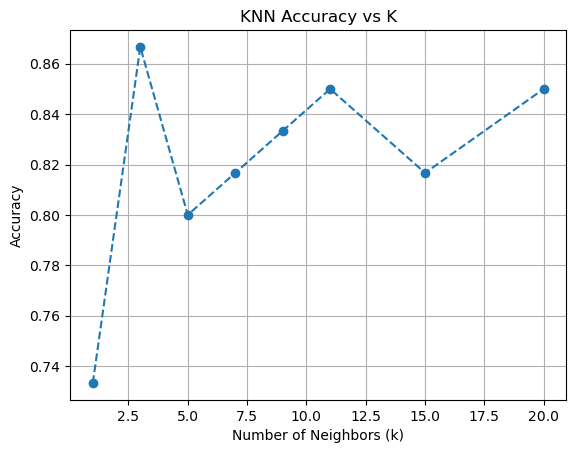

In [17]:
# 1. Create dataset
X, y = make_classification(n_features=2, n_redundant=0, n_informative=2,
                           n_clusters_per_class=1, n_samples=200, random_state=42)

# 2. Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Try different values of k
k_values = [1, 3, 5, 7, 9, 11, 15, 20]
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"k={k} → Accuracy={acc:.2f}")

# 4. Plot Accuracy vs k
plt.plot(k_values, accuracies, marker='o', linestyle='--')
plt.title("KNN Accuracy vs K")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

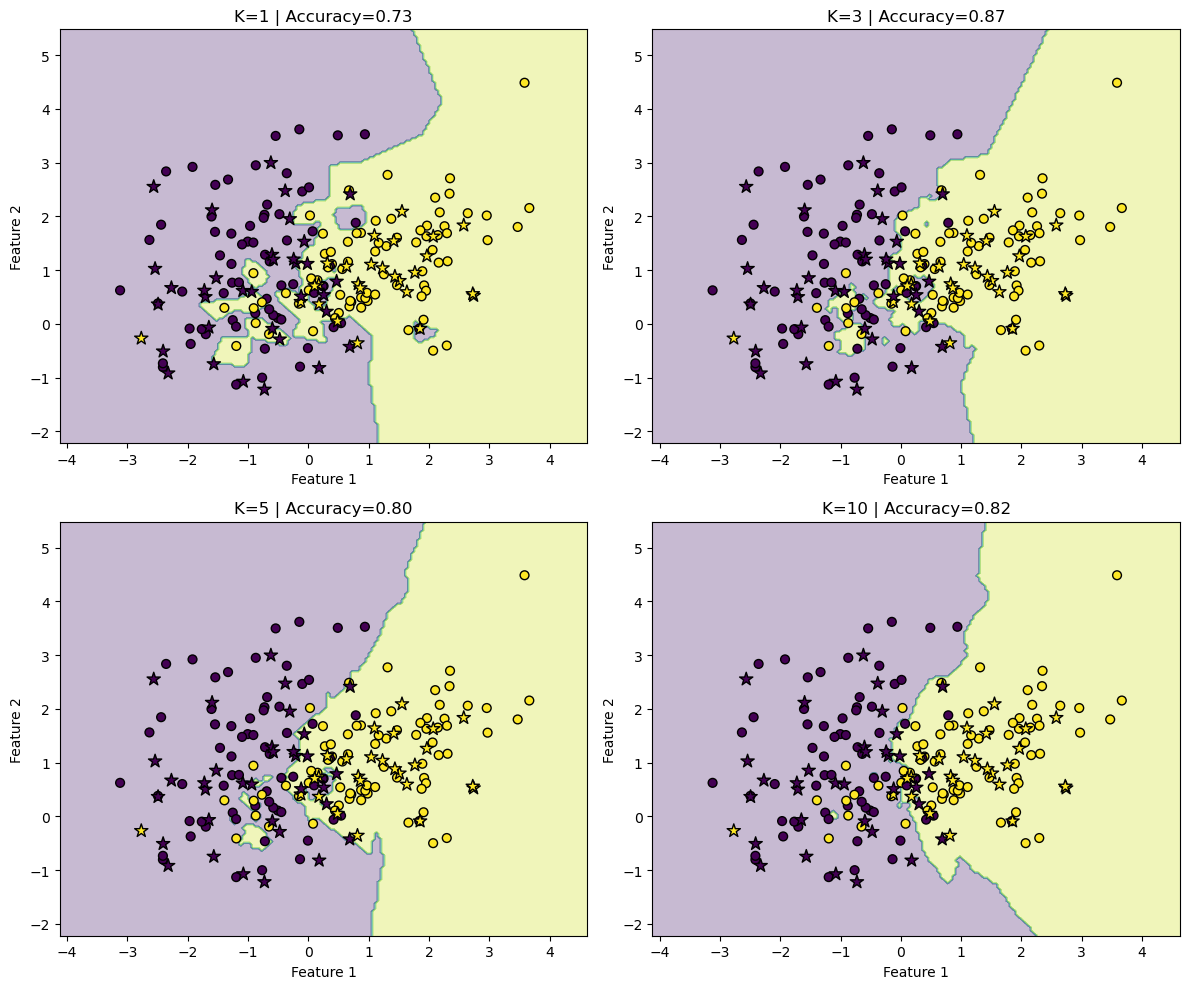

In [7]:
# 1. Create dataset
X, y = make_classification(n_features=2, n_redundant=0, n_informative=2,
                           n_clusters_per_class=1, n_samples=200, random_state=42)

# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Values of k to test
k_values = [1, 3, 5, 10]

# 4. Create subplots
plt.figure(figsize=(12, 10))

for i, k in enumerate(k_values, 1):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    # Create mesh grid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                         np.arange(y_min, y_max, 0.05))
    
    # Predict for grid
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot decision boundary
    plt.subplot(2, 2, i)
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolor='k', s=40, label="Train")
    plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolor='k', s=100, marker='*', label="Test")
    plt.title(f"K={k} | Accuracy={acc:.2f}")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")

plt.tight_layout()
plt.show()


✅ Best K = 12 with CV Accuracy = 0.86
🎯 Test Accuracy with K=12: 0.87


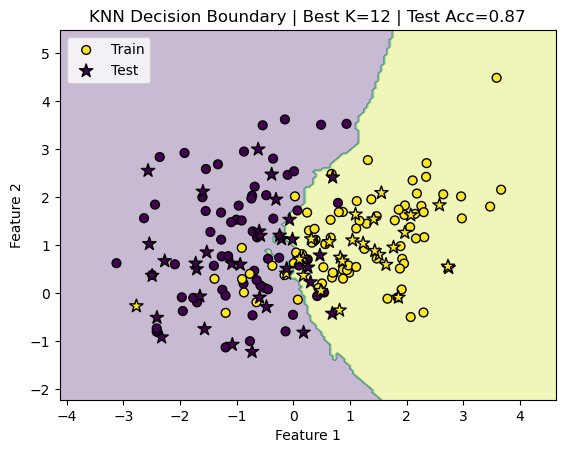

In [16]:
# 1. Create dataset (2 features for easy visualization)
X, y = make_classification(n_features=2, n_redundant=0, n_informative=2,
                           n_clusters_per_class=1, n_samples=200, random_state=42)

# 2. Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Range of k values to test
k_values = range(1, 21)
cv_scores = []

# 4. Cross-validation for each k
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

# 5. Best k
best_k = k_values[np.argmax(cv_scores)]
best_cv_score = max(cv_scores)
print(f"✅ Best K = {best_k} with CV Accuracy = {best_cv_score:.2f}")

# 6. Retrain model with best k on full training set
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train, y_train)

# 7. Evaluate on test set
y_pred = best_knn.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print(f"🎯 Test Accuracy with K={best_k}: {test_acc:.2f}")

# 8. Create mesh grid for decision boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

Z = best_knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 9. Plot decision boundary + data
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolor='k', s=40, label="Train")
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolor='k', s=100, marker='*', label="Test")
plt.title(f"KNN Decision Boundary | Best K={best_k} | Test Acc={test_acc:.2f}")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()


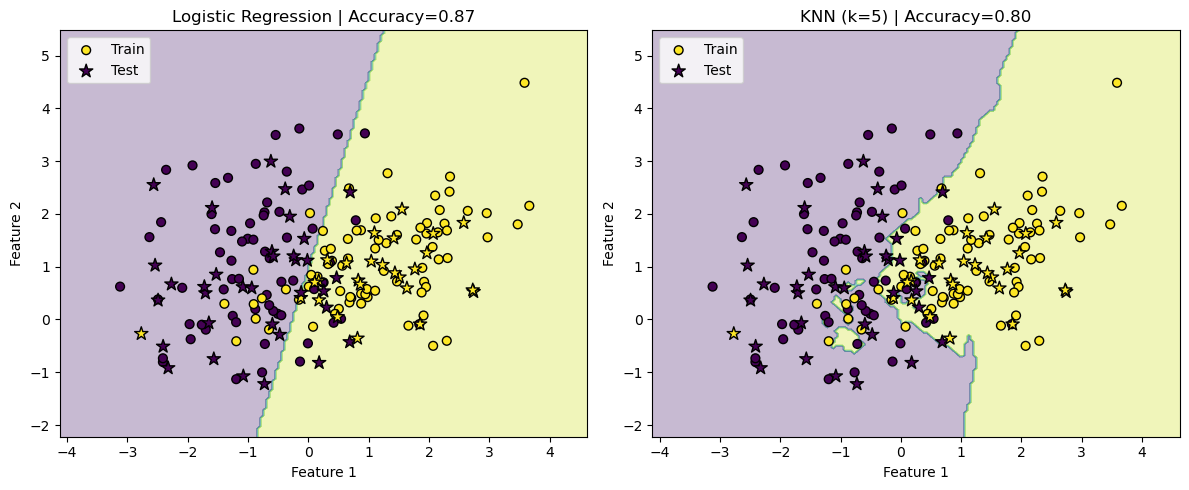

In [15]:
# 1. Create a 2D dataset
X, y = make_classification(n_features=2, n_redundant=0, n_informative=2,
                           n_clusters_per_class=1, n_samples=200, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Define models
log_reg = LogisticRegression()
knn = KNeighborsClassifier(n_neighbors=5)

# 3. Train models
log_reg.fit(X_train, y_train)
knn.fit(X_train, y_train)

# 4. Predictions and accuracy
y_pred_log = log_reg.predict(X_test)
y_pred_knn = knn.predict(X_test)

acc_log = accuracy_score(y_test, y_pred_log)
acc_knn = accuracy_score(y_test, y_pred_knn)

# 5. Create mesh grid for plotting
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

# 6. Predictions for grid points
Z_log = log_reg.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
Z_knn = knn.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# 7. Plot decision boundaries
plt.figure(figsize=(12, 5))

# Logistic Regression
plt.subplot(1, 2, 1)
plt.contourf(xx, yy, Z_log, alpha=0.3)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolor='k', s=40, label="Train")
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, marker="*", s=100, edgecolor='k', label="Test")
plt.title(f"Logistic Regression | Accuracy={acc_log:.2f}")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()

# KNN
plt.subplot(1, 2, 2)
plt.contourf(xx, yy, Z_knn, alpha=0.3)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolor='k', s=40, label="Train")
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, marker="*", s=100, edgecolor='k', label="Test")
plt.title(f"KNN (k=5) | Accuracy={acc_knn:.2f}")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()

plt.tight_layout()
plt.show()
